In [1]:
# -----Import Libraries----
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn

import warnings
warnings.filterwarnings("ignore")

In [5]:
#---Load dataset---
df = pd.read_csv("../data/raw/ecommerce_inventory_demand.csv")

# First 5 rows
print(df.head())

# Shape of dataset
print(df.shape)

# Column names
print(df.columns)


# --- Missing Values ---
print("\nMissing Values")
print(df.isnull().sum())

# --- Dataset Information ---
print("\nDataset Info")
print(df.info())

# --- Statistical Summary ---
print("\nStatistical Summary")
print(df.describe())

         date product_id product_category  units_sold  unit_price  \
0  2022-06-27       P006      Electronics         NaN    10225.02   
1  2023-06-14       P028          Apparel         NaN     1137.33   
2  2022-06-20       P005      Electronics         NaN     8245.58   
3  2022-03-06       P039             Home         NaN     2657.76   
4  2022-05-01       P015      Electronics         NaN    12117.51   

   stock_on_hand  reorder_point  is_promotion  discount_pct  day_of_week  \
0            203             79             0           0.0            0   
1            108             51             0           0.0            2   
2            274             72             0           0.0            0   
3            179             43             0           0.0            6   
4            205             52             0           0.0            6   

   month  supplier_lead_days  
0      6                  13  
1      6                   8  
2      6                   9  
3   


Numeric Columns:
Index(['units_sold', 'unit_price', 'stock_on_hand', 'reorder_point',
       'is_promotion', 'discount_pct', 'day_of_week', 'month',
       'supplier_lead_days'],
      dtype='object')

Using 'units_sold' as sales column

Categorical Columns:
Index(['date', 'product_id', 'product_category'], dtype='object')

Using 'date' as category column


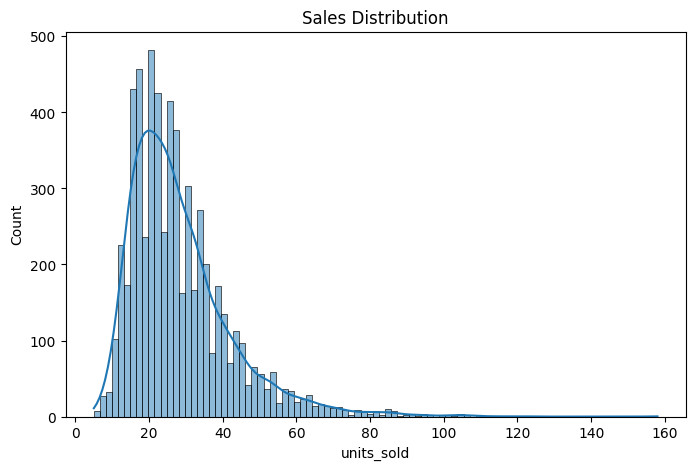

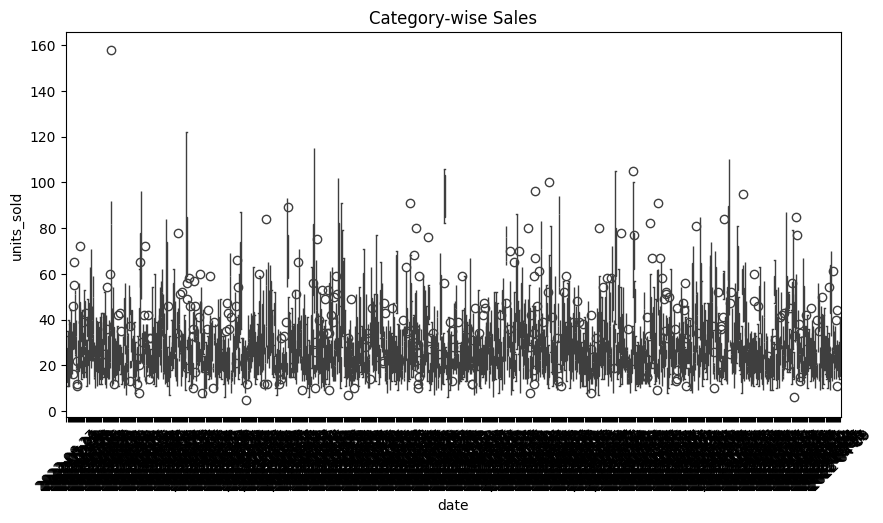

In [6]:
# ---------------------------------------------------
# AUTOMATIC COLUMN DETECTION
# ---------------------------------------------------

# Select numeric columns
numeric_columns = df.select_dtypes(include='number').columns

print("\nNumeric Columns:")
print(numeric_columns)

# Select first numeric column
sales_column = numeric_columns[0]

print(f"\nUsing '{sales_column}' as sales column")

# Select categorical columns
categorical_columns = df.select_dtypes(include='object').columns

print("\nCategorical Columns:")
print(categorical_columns)

# Select first categorical column
category_column = categorical_columns[0]

print(f"\nUsing '{category_column}' as category column")

# ---------------------------------------------------
# SALES DISTRIBUTION
# ---------------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(df[sales_column], kde=True)

plt.title("Sales Distribution")

plt.xlabel(sales_column)

plt.ylabel("Count")

plt.show()

# ---------------------------------------------------
# CATEGORY-WISE SALES
# ---------------------------------------------------

plt.figure(figsize=(10,5))

sns.boxplot(
    x=category_column,
    y=sales_column,
    data=df
)

plt.xticks(rotation=45)

plt.title("Category-wise Sales")

plt.show()

In [7]:
#Data Cleaning
#Fill Missing Values
df.fillna(method='ffill', inplace=True)

#Removes Duplicates
df.drop_duplicates(inplace=True)

In [9]:
# ---------------------------------------------------
# Detect Numeric Column Automatically
# ---------------------------------------------------

numeric_columns = df.select_dtypes(include='number').columns

print("Numeric Columns:")
print(numeric_columns)

# Select first numeric column
sales_column = numeric_columns[0]

print(f"Using '{sales_column}' as sales column")

# ---------------------------------------------------
# Detect Date Column Automatically
# ---------------------------------------------------

date_column = None

for col in df.columns:

    if 'date' in col.lower():

        date_column = col

        break

print(f"Using '{date_column}' as date column")

# ---------------------------------------------------
# Create Lag Features
# ---------------------------------------------------

df['lag_7'] = df[sales_column].shift(7)

df['lag_14'] = df[sales_column].shift(14)

# ---------------------------------------------------
# Rolling Mean
# ---------------------------------------------------

df['rolling_mean_7'] = (
    df[sales_column]
    .rolling(window=7)
    .mean()
)

# ---------------------------------------------------
# Date Features
# ---------------------------------------------------

if date_column is not None:

    df[date_column] = pd.to_datetime(df[date_column])

    # Weekend feature
    df['is_weekend'] = (
        df[date_column]
        .dt.dayofweek >= 5
    )

    # Month feature
    df['month'] = (
        df[date_column]
        .dt.month
    )

# ---------------------------------------------------
# Remove Null Values
# ---------------------------------------------------

df.dropna(inplace=True)

# ---------------------------------------------------
# Show Output
# ---------------------------------------------------

print(df.head())

print("Feature Engineering Completed Successfully")

Numeric Columns:
Index(['units_sold', 'unit_price', 'stock_on_hand', 'reorder_point',
       'is_promotion', 'discount_pct', 'day_of_week', 'month',
       'supplier_lead_days'],
      dtype='object')
Using 'units_sold' as sales column
Using 'date' as date column
          date product_id product_category  units_sold  unit_price  \
263 2023-04-29       P031          Apparel        35.0      721.74   
264 2023-07-10       P001      Electronics        19.0    23619.66   
265 2023-06-19       P005      Electronics        10.0     8003.85   
266 2022-07-14       P035           Sports        15.0     1762.25   
267 2023-01-09       P016      Electronics        13.0     8937.78   

     stock_on_hand  reorder_point  is_promotion  discount_pct  day_of_week  \
263            137             47             0           0.0            5   
264            118             45             0           0.0            0   
265            294             72             0           0.0            0   
266

In [11]:
# ---------------------------------------------------
# Detect Categorical Columns
# ---------------------------------------------------

categorical_columns = (
    df.select_dtypes(include='object')
    .columns
)

print("Categorical Columns:")
print(categorical_columns)

# One Hot Encoding
if len(categorical_columns) > 0:

    df = pd.get_dummies(
        df,
        columns=categorical_columns
    )

# ---------------------------------------------------
# Detect Numeric Columns
# ---------------------------------------------------

numeric_columns = (
    df.select_dtypes(include='number')
    .columns
)

print("\nNumeric Columns:")
print(numeric_columns)

# Select first numeric column
sales_column = numeric_columns[0]

print(f"\nUsing '{sales_column}' for scaling")

# ---------------------------------------------------
# Scaling
# ---------------------------------------------------

scaler = MinMaxScaler()

df[sales_column] = scaler.fit_transform(
    df[[sales_column]]
)

# ---------------------------------------------------
# Output
# ---------------------------------------------------

print("\nScaled Dataset:")
print(df.head())

print("\nEncoding and Scaling Completed Successfully")

Categorical Columns:
Index(['product_id', 'product_category'], dtype='object')

Numeric Columns:
Index(['units_sold', 'unit_price', 'stock_on_hand', 'reorder_point',
       'is_promotion', 'discount_pct', 'day_of_week', 'month',
       'supplier_lead_days', 'lag_7', 'lag_14', 'rolling_mean_7'],
      dtype='object')

Using 'units_sold' for scaling

Scaled Dataset:
          date  units_sold  unit_price  stock_on_hand  reorder_point  \
263 2023-04-29    0.196078      721.74            137             47   
264 2023-07-10    0.091503    23619.66            118             45   
265 2023-06-19    0.032680     8003.85            294             72   
266 2022-07-14    0.065359     1762.25            261             76   
267 2023-01-09    0.052288     8937.78            134             43   

     is_promotion  discount_pct  day_of_week  month  supplier_lead_days  ...  \
263             0           0.0            5      4                  13  ...   
264             0           0.0         

In [12]:
#---Load dataset---
df = pd.read_csv("../data/raw/ecommerce_inventory_demand.csv")

# First 5 rows
print(df.head())

# Shape of dataset
print(df.shape)

# Column names
print(df.columns)


# --- Missing Values ---
print("\nMissing Values")
print(df.isnull().sum())

# --- Dataset Information ---
print("\nDataset Info")
print(df.info())

# --- Statistical Summary ---
print("\nStatistical Summary")
print(df.describe())

         date product_id product_category  units_sold  unit_price  \
0  2022-06-27       P006      Electronics         NaN    10225.02   
1  2023-06-14       P028          Apparel         NaN     1137.33   
2  2022-06-20       P005      Electronics         NaN     8245.58   
3  2022-03-06       P039             Home         NaN     2657.76   
4  2022-05-01       P015      Electronics         NaN    12117.51   

   stock_on_hand  reorder_point  is_promotion  discount_pct  day_of_week  \
0            203             79             0           0.0            0   
1            108             51             0           0.0            2   
2            274             72             0           0.0            0   
3            179             43             0           0.0            6   
4            205             52             0           0.0            6   

   month  supplier_lead_days  
0      6                  13  
1      6                   8  
2      6                   9  
3   

In [13]:
#Train-Test Split

#Time Series Split
train_size = int(len(df) * 0.8)

train_data = df[:train_size]

test_data = df[train_size:]

In [14]:
#Prepare Sequences for LSTM
def create_sequences(data, seq_length):

    xs = []
    ys = []

    for i in range(len(data)-seq_length):

        x = data[i:i+seq_length]
        y = data[i+seq_length]

        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys)

In [15]:
#Build LSTM Model
class LSTMModel(nn.Module):

    def __init__(self):

        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = self.fc(out[:, -1, :])

        return out

In [20]:


# ---------------------------------------------------
# Load Dataset
# ---------------------------------------------------

df = pd.read_csv("../data/processed/final_data.csv")

# ---------------------------------------------------
# Remove NaN and Infinite Values
# ---------------------------------------------------

df = df.replace([np.inf, -np.inf], np.nan)

df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

# ---------------------------------------------------
# Detect Numeric Column
# ---------------------------------------------------

numeric_columns = df.select_dtypes(include='number').columns

sales_column = numeric_columns[0]

print(f"Using '{sales_column}' as target")

# ---------------------------------------------------
# Scaling
# ---------------------------------------------------

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df[[sales_column]]
)

# ---------------------------------------------------
# Create Sequences
# ---------------------------------------------------

sequence_length = 10

X = []
y = []

for i in range(len(scaled_data) - sequence_length):

    X.append(
        scaled_data[i:i+sequence_length]
    )

    y.append(
        scaled_data[i+sequence_length]
    )

X = np.array(X)

y = np.array(y)

# ---------------------------------------------------
# Convert to Tensors
# ---------------------------------------------------

X_train = torch.tensor(
    X,
    dtype=torch.float32
)

y_train = torch.tensor(
    y,
    dtype=torch.float32
)

# ---------------------------------------------------
# Check NaN
# ---------------------------------------------------

print("NaN in X_train:",
      torch.isnan(X_train).any())

print("NaN in y_train:",
      torch.isnan(y_train).any())

# ---------------------------------------------------
# LSTM Model
# ---------------------------------------------------

class LSTMModel(nn.Module):

    def __init__(self):

        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = self.fc(out[:, -1, :])

        return out

# ---------------------------------------------------
# Train Model
# ---------------------------------------------------

model = LSTMModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 20

for epoch in range(epochs):

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    print(
        f"Epoch {epoch+1}, Loss: {loss.item()}"
    )

print("Training Completed Successfully")

Using 'units_sold' as target
NaN in X_train: tensor(False)
NaN in y_train: tensor(False)
Epoch 1, Loss: 0.0826728492975235
Epoch 2, Loss: 0.0691530704498291
Epoch 3, Loss: 0.056908681988716125
Epoch 4, Loss: 0.04582784324884415
Epoch 5, Loss: 0.035899464040994644
Epoch 6, Loss: 0.02716914936900139
Epoch 7, Loss: 0.019766539335250854
Epoch 8, Loss: 0.013929558917880058
Epoch 9, Loss: 0.010012401267886162
Epoch 10, Loss: 0.008436337113380432
Epoch 11, Loss: 0.009420243091881275
Epoch 12, Loss: 0.01219947636127472
Epoch 13, Loss: 0.014733816497027874
Epoch 14, Loss: 0.01559420581907034
Epoch 15, Loss: 0.014834501780569553
Epoch 16, Loss: 0.0131986103951931
Epoch 17, Loss: 0.011419463902711868
Epoch 18, Loss: 0.0099572679027915
Epoch 19, Loss: 0.008993426337838173
Epoch 20, Loss: 0.0085184620693326
Training Completed Successfully


In [21]:
# ---------------------------------------------------
# Predictions
# ---------------------------------------------------

model.eval()

with torch.no_grad():

    predictions = model(X_train)

# Convert tensors to numpy
predictions = predictions.numpy()

y_test = y_train.numpy()

# ---------------------------------------------------
# Evaluation Metrics
# ---------------------------------------------------

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

# MAE
mae = mean_absolute_error(
    y_test,
    predictions
)

print("MAE:", mae)

# RMSE
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("RMSE:", rmse)

MAE: 0.06697539985179901
RMSE: 0.0917984475346057


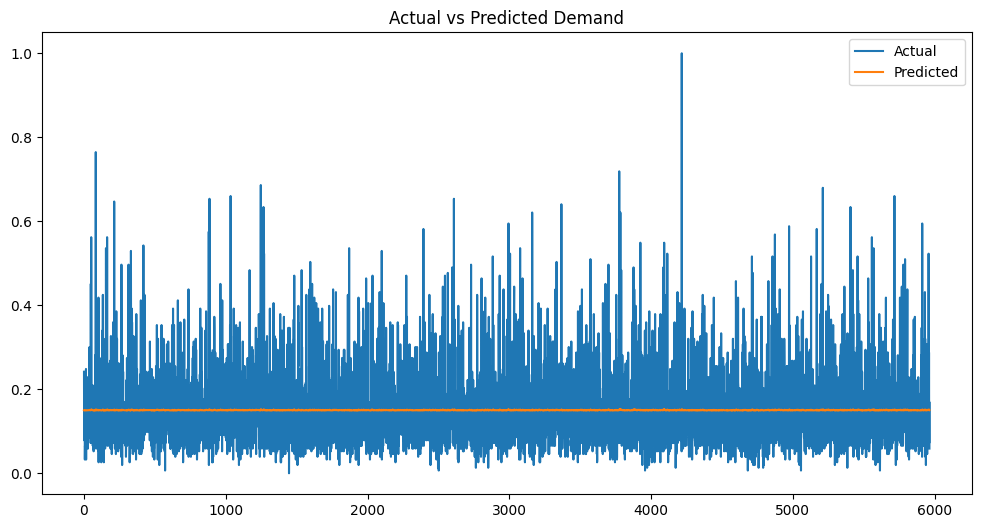

In [22]:
#Actual vs Predicted Graph
plt.figure(figsize=(12,6))

plt.plot(y_test, label='Actual')

plt.plot(predictions, label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Demand")

plt.show()
